# Linear Warp Convergence
Time evolution of the disk inclination $\beta$ at $r=1.5$ for simulation C03, showing initially damped oscillations on a $t \sim 100$ timescale before settling into a quasi-steady state.

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 18})

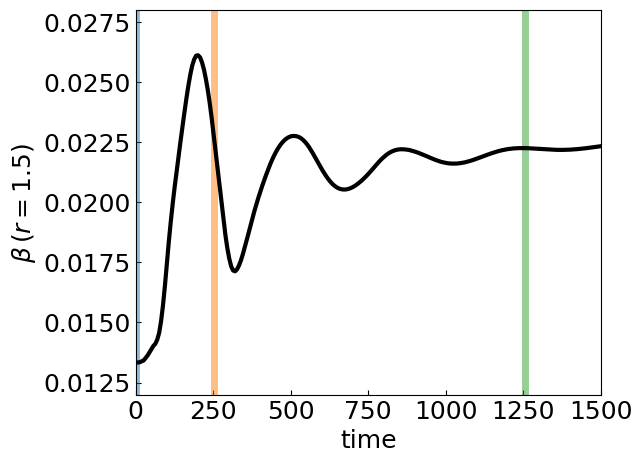

In [2]:
def load_convergence_series(snapshot_paths, r_check=1.5):
    times = []
    beta_values = []

    for path in snapshot_paths:
        res = np.load(path, allow_pickle=True).item()

        t_sim = res["profiles"]["t"]
        r_sim = res["profiles"]["rad_app"]
        l_hat = res["vectors"]["l_hat"]

        beta_sim = np.arccos(l_hat[2, :])

        times.append(t_sim)
        beta_values.append(np.abs(np.interp(r_check, r_sim, beta_sim)))

    times = np.asarray(times)
    beta_values = np.asarray(beta_values)

    order = np.argsort(times)
    return times[order], beta_values[order]


def plot_convergence(ax, snapshot_paths, color="k", r_check=1.5, time_offset=0.0):
    times, beta_values = load_convergence_series(snapshot_paths, r_check=r_check)

    ax.plot(times + time_offset, beta_values, c=color, lw=3, zorder=10)

    for x, c in zip([0.0, 251.2, 1256.0], ["C0", "C1", "C2"]):
        ax.axvline(x=x, c=c, lw=5, alpha=0.5)

    ax.set_xlim(0, 1500)
    ax.set_ylim(0.012, 0.028)
    ax.set_xlabel("time")
    ax.set_ylabel(r"$\beta\,(r=1.5)$")
    ax.tick_params(which="both", direction="in")


snapshot_paths = sorted(glob.glob("../data/sim002t-const-alpha-t*-res.npy"))

fig, ax = plt.subplots(figsize=(6, 5))
plot_convergence(ax, snapshot_paths, color="k", r_check=1.5)
plt.show()